**Initial setup for all of continental USA, not just Florida anymore.**
- 14 May 2026

In [2]:
# --- Cell 1: Load POUS and print basic checks ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File path for the county x storm event dataset
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"

# Load POUS
pous = pd.read_csv(pous_path)

# Standardise FIPS as strings with leading zeros preserved
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)

# Parse event_start as datetime
pous["event_start"] = pd.to_datetime(pous["event_start"])

# Basic sanity checks
print("POUS shape:", pous.shape)
print("\nColumns:")
print(pous.columns.tolist())

print("\nDtypes:")
print(pous.dtypes)

print("\nHead:")
print(pous.head())

print("\nDate range:")
print("Start:", pous["event_start"].min())
print("End:  ", pous["event_start"].max())

print("\nUnique counties:", pous["CountyFIPS"].nunique())
print("Unique storms:   ", pous["storm"].nunique())
print("Unique events:   ", pous.groupby(["CountyFIPS", "storm"]).ngroups)

print("\nMissing values per column:")
print(pous.isna().sum())

POUS shape: (1040, 13)

Columns:
['event_start', 'CountyFIPS', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'duration_hours', 'n_periods', 'integral', 'pop_hours_supply_lost', 'storm', 'duration_days', 'year', 'month']

Dtypes:
event_start                     datetime64[us]
CountyFIPS                                 str
county_pop                               int64
pre_outage_tracked_customers           float64
days_since_data_start                  float64
duration_hours                           int64
n_periods                                int64
integral                               float64
pop_hours_supply_lost                  float64
storm                                      str
duration_days                          float64
year                                     int64
month                                    int64
dtype: object

Head:
          event_start CountyFIPS  county_pop  pre_outage_tracked_customers  \
0 2017-06-21 16:00:00      54001    

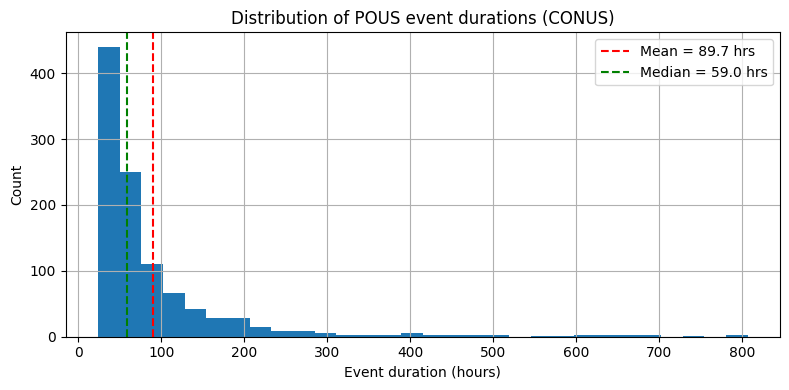

Duration summary:
count    1040.000000
mean       89.707692
std        99.504640
min        24.000000
25%        37.750000
50%        59.000000
75%        98.250000
max       807.000000
Name: duration_hours, dtype: float64

Mean duration:   89.71 hrs
Median duration: 59.00 hrs
Std dev:         99.50 hrs


In [3]:
# --- Cell 2: Histogram of event duration ---

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# Event duration distribution
pous["duration_hours"].hist(bins=30)

# Summary statistics for the plot
mean_val = pous["duration_hours"].mean()
median_val = pous["duration_hours"].median()
std_val = pous["duration_hours"].std()

# Reference lines
plt.axvline(mean_val, linestyle="--", color="red", label=f"Mean = {mean_val:.1f} hrs")
plt.axvline(median_val, linestyle="--", color="green", label=f"Median = {median_val:.1f} hrs")

plt.xlabel("Event duration (hours)")
plt.ylabel("Count")
plt.title("Distribution of POUS event durations (CONUS)")
plt.legend()
plt.tight_layout()
plt.show()

print("Duration summary:")
print(pous["duration_hours"].describe())
print(f"\nMean duration:   {mean_val:.2f} hrs")
print(f"Median duration: {median_val:.2f} hrs")
print(f"Std dev:         {std_val:.2f} hrs")

In [4]:
# --- Cell 3: Quick state-level event counts (useful CONUS sanity check) ---

# FIPS -> state code mapping
fips_to_state = {
    "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT","10":"DE",
    "11":"DC","12":"FL","13":"GA","15":"HI","16":"ID","17":"IL","18":"IN","19":"IA",
    "20":"KS","21":"KY","22":"LA","23":"ME","24":"MD","25":"MA","26":"MI","27":"MN",
    "28":"MS","29":"MO","30":"MT","31":"NE","32":"NV","33":"NH","34":"NJ","35":"NM",
    "36":"NY","37":"NC","38":"ND","39":"OH","40":"OK","41":"OR","42":"PA","44":"RI",
    "45":"SC","46":"SD","47":"TN","48":"TX","49":"UT","50":"VT","51":"VA","53":"WA",
    "54":"WV","55":"WI","56":"WY"
}

# Extract state FIPS from county code
pous["state_fips"] = pous["CountyFIPS"].str[:2]
pous["state"] = pous["state_fips"].map(fips_to_state)

state_counts = (
    pous.groupby(["state", "state_fips"])
    .size()
    .reset_index(name="n_events")
    .sort_values("n_events", ascending=False)
)

print("Top 10 states by number of POUS events:")
print(state_counts.head(10).to_string(index=False))

fl = state_counts.loc[state_counts["state"] == "FL", "n_events"]
if not fl.empty:
    print(f"\nFlorida event count: {int(fl.iloc[0])}")

Top 10 states by number of POUS events:
state state_fips  n_events
   GA         13       179
   LA         22       162
   NC         37       132
   FL         12        99
   VA         51        85
   MS         28        79
   AL         01        63
   TX         48        56
   SC         45        37
   AR         05        23

Florida event count: 99


In [7]:
# --- Cell 1: Imports, paths, POUS load, parquet dataset setup ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Efficient parquet access for the very large CONUS time series file
import pyarrow.dataset as ds

# File paths
ts_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq"
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"

# Load POUS event-level file so we can sample county-storm windows to inspect
pous = pd.read_csv(pous_path)
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

print("Loaded POUS shape:", pous.shape)
print("Event start range:", pous["event_start"].min(), "to", pous["event_start"].max())
print("Unique counties:", pous["CountyFIPS"].nunique())
print("Unique storms:", pous["storm"].nunique())

# Create the parquet dataset object once; do not load the full 160M-row file into memory
ts_dataset = ds.dataset(ts_path, format="parquet")

# Helpful check on the parquet schema
print("\nParquet schema fields:")
print(ts_dataset.schema.names)

def load_time_series_window(county_fips, event_start, days_before=3, days_after=14):
    """
    Load a small time window for one county directly from the parquet file.

    Important:
    - The parquet file may reconstruct RecordDateTime / CountyFIPS as an index
      when converted back to pandas.
    - We therefore reset the index if those fields are not already columns.
    """
    event_start = pd.Timestamp(event_start)
    window_start = event_start - pd.Timedelta(days=days_before)
    window_end = event_start + pd.Timedelta(days=days_after)

    # Filter the large parquet dataset before materialising into pandas
    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start.to_pydatetime()) &
        (ds.field("RecordDateTime") <= window_end.to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()

    if out.empty:
        return out

    # When pandas reconstructs the parquet index, these fields may not be columns yet
    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

Loaded POUS shape: (1040, 13)
Event start range: 2017-06-21 16:00:00 to 2022-10-01 02:00:00
Unique counties: 675
Unique storms: 35

Parquet schema fields:
['OutageFraction', 'CustomersTracked', 'RecordDateTime', 'CountyFIPS']


Random sample of 20 events:
        storm CountyFIPS         event_start  duration_hours
2017242N16333      13091 2017-09-11 14:00:00              58
2020233N14313      22045 2020-08-27 07:00:00              56
2018146N19273      21039 2018-05-27 13:00:00              34
2017228N14314      28053 2017-09-01 00:00:00              24
2020233N14313      05147 2020-08-28 01:00:00              70
2021239N17281      22117 2021-08-29 21:00:00             240
2018280N18273      13037 2018-10-10 21:00:00             195
2018280N18273      13023 2018-10-11 04:00:00              64
2019299N25265      28065 2019-10-26 13:00:00              53
2018280N18273      51073 2018-10-12 01:00:00              96
2020233N14313      05027 2020-08-27 17:00:00              56
2020211N13306      37187 2020-08-04 09:00:00              37
2020299N18277      37035 2020-10-29 14:00:00              58
2020279N16284      28113 2020-10-10 05:00:00              37
2018242N13343      51077 2018-09-17 02:00:00             

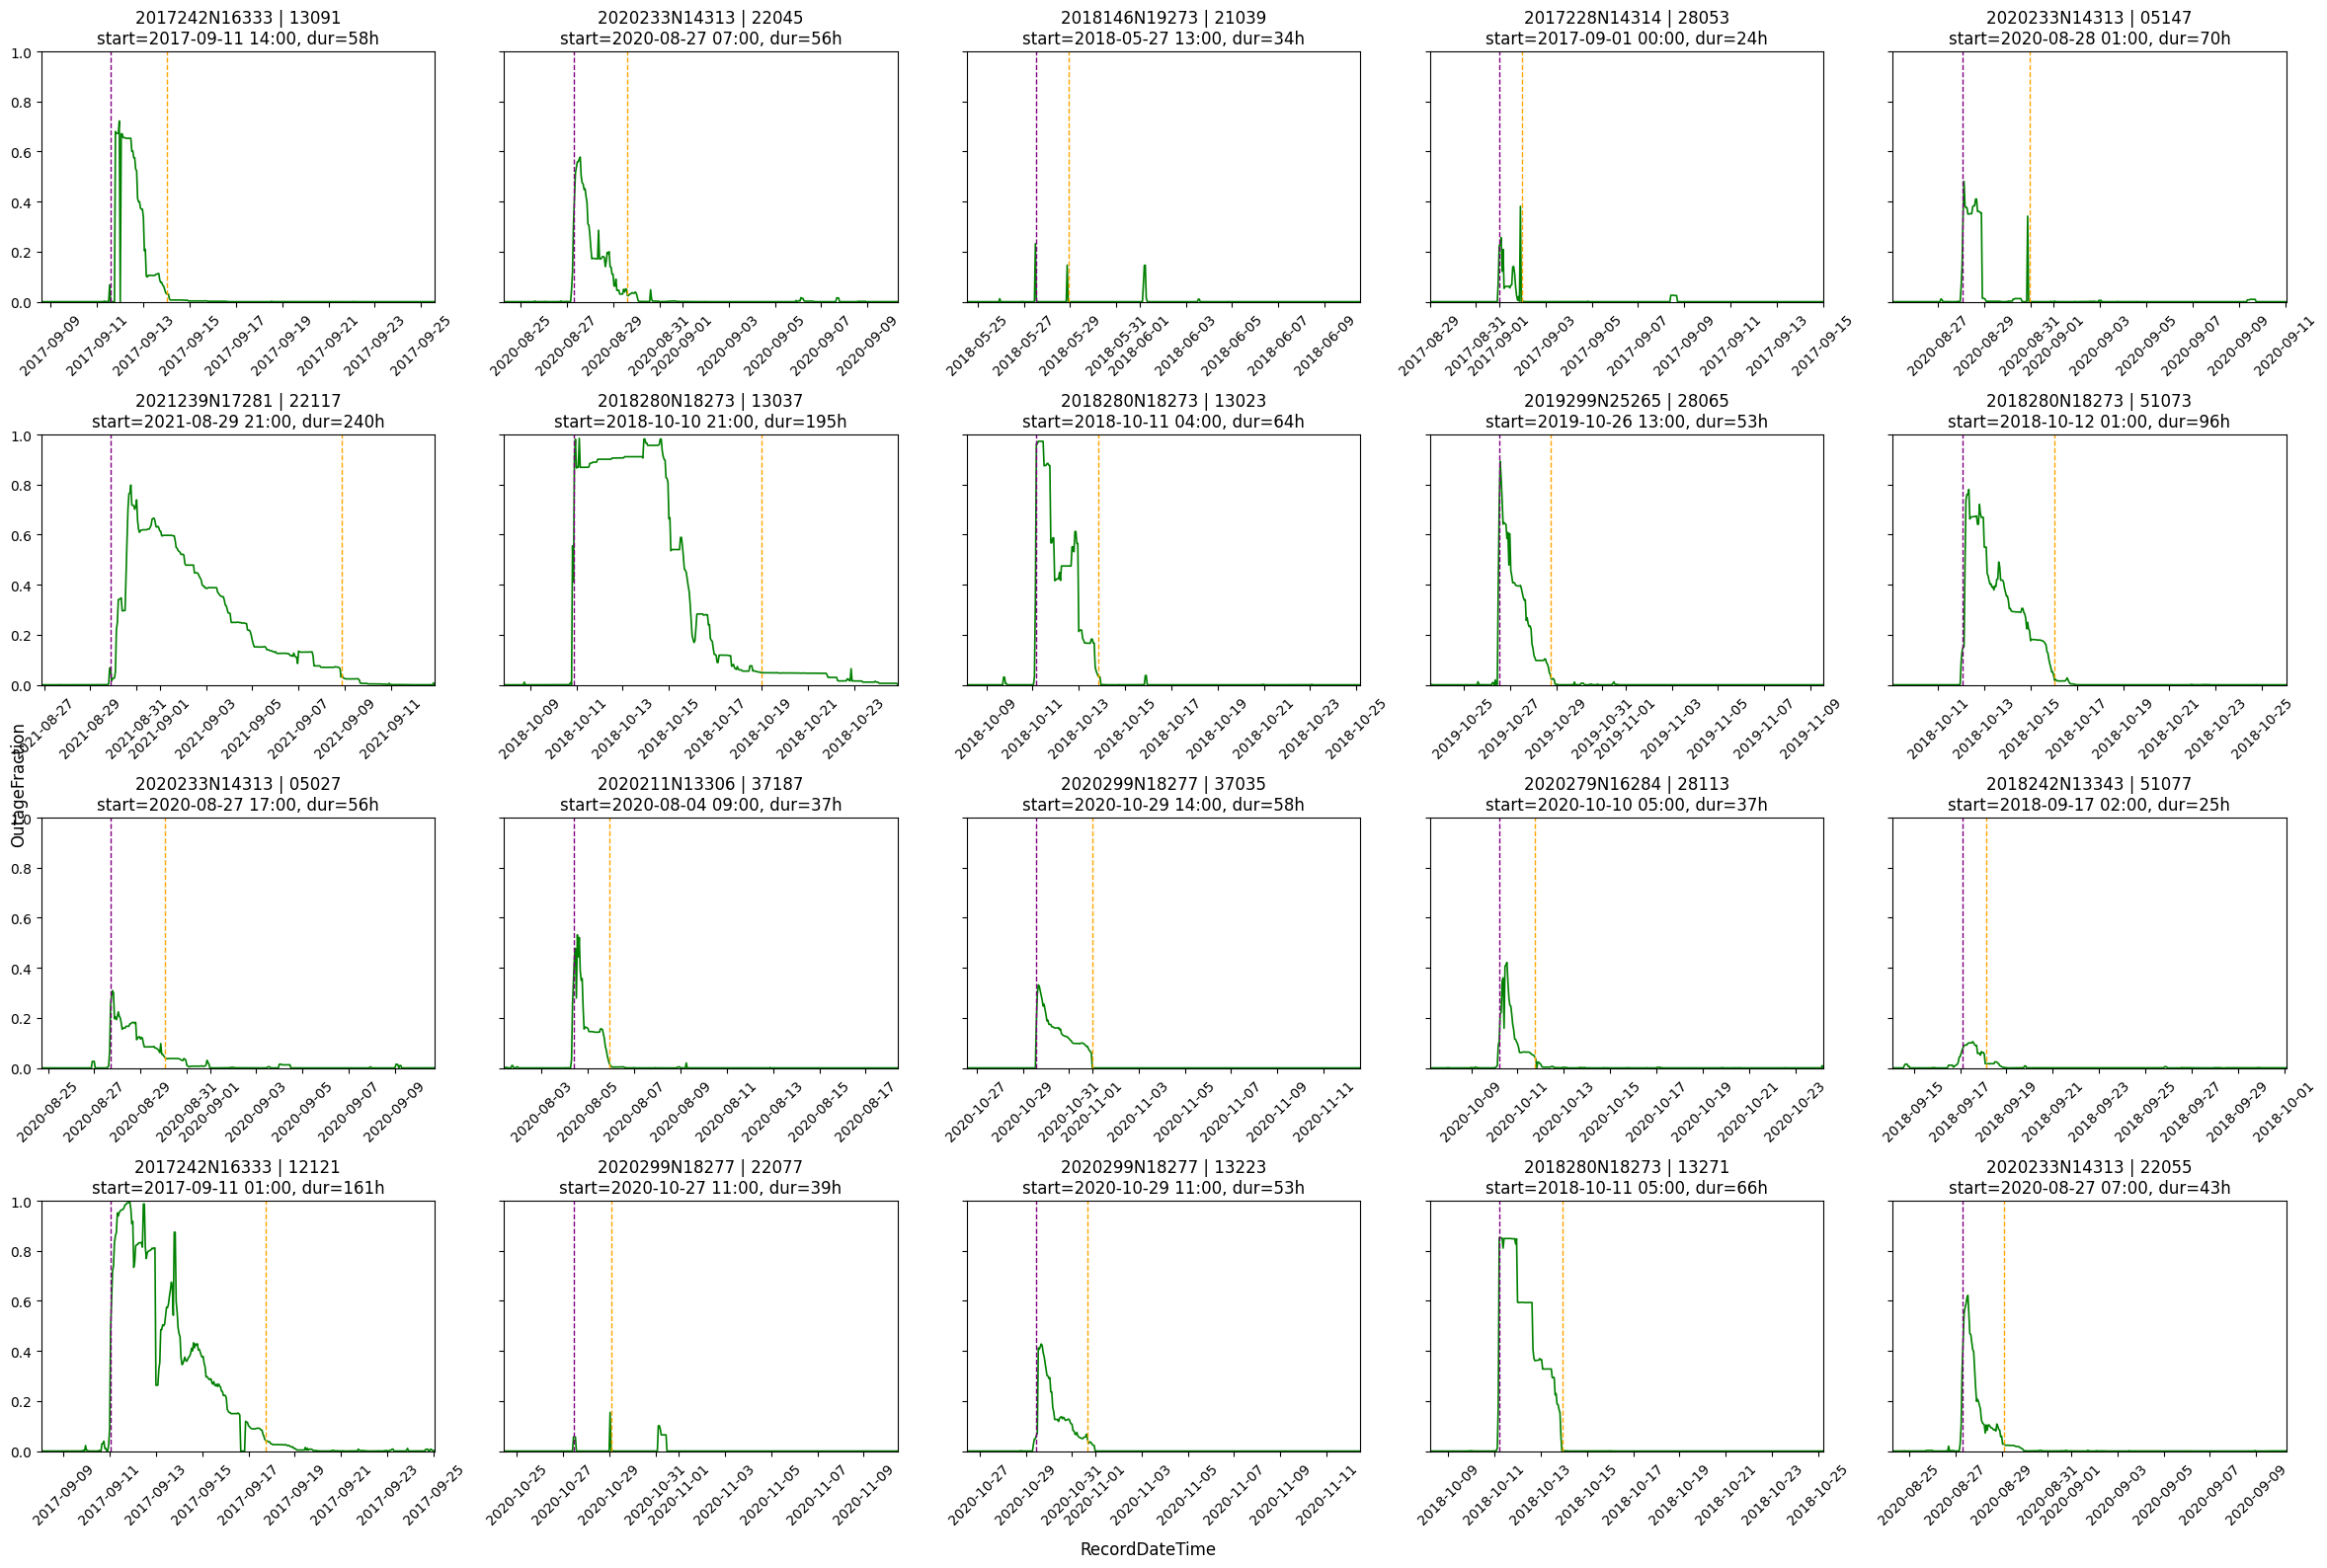


Plotted 20 county-event time series windows.


In [9]:
# --- Cell 2: Plot 20 random time series windows (4 x 5 grid) ---

# Toggle window type:
#   "fixed" = plot a fixed time window after event start
#   "event" = plot only until the end of the event using POUS duration_hours
WINDOW_MODE = "fixed"   # change to "event" if you want to plot to the event end

# Fixed-window settings (used only when WINDOW_MODE == "fixed")
days_before = 3
days_after = 14

# Randomly sample 20 county-storm events to inspect
sample_events = pous.sample(n=20, random_state=42).reset_index(drop=True)

print("Random sample of 20 events:")
print(sample_events[["storm", "CountyFIPS", "event_start", "duration_hours"]].to_string(index=False))

fig, axes = plt.subplots(4, 5, figsize=(24, 16), sharey=True)
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

n_plotted = 0

for ax, (_, row) in zip(axes, sample_events.iterrows()):
    county_fips = row["CountyFIPS"]
    event_start = row["event_start"]
    storm = row["storm"]
    duration_hours = row["duration_hours"]

    # Choose end of plotted window
    if WINDOW_MODE == "fixed":
        window_start = event_start - pd.Timedelta(days=days_before)
        window_end = event_start + pd.Timedelta(days=days_after)
    elif WINDOW_MODE == "event":
        window_start = event_start - pd.Timedelta(days=days_before)
        window_end = event_start + pd.Timedelta(hours=float(duration_hours))
    else:
        raise ValueError("WINDOW_MODE must be 'fixed' or 'event'.")

    g = load_time_series_window(
        county_fips=county_fips,
        event_start=event_start,
        days_before=days_before,
        days_after=(days_after if WINDOW_MODE == "fixed" else int(np.ceil(duration_hours / 24)) + 1),
    )

    ax.set_visible(True)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlim(window_start, window_end)

    if g.empty:
        ax.set_title(f"{storm} | {county_fips}\n(no data returned)")
        continue

    # Plot outage fraction over time
    ax.plot(g["RecordDateTime"], g["OutageFraction"], color="green", linewidth=1.2)

    # Event start line
    ax.axvline(event_start, color="purple", linestyle="--", linewidth=1)

    # Event end line (based on POUS duration)
    event_end = event_start + pd.Timedelta(hours=float(duration_hours))
    ax.axvline(event_end, color="orange", linestyle="--", linewidth=1)

    ax.set_title(
        f"{storm} | {county_fips}\n"
        f"start={event_start.strftime('%Y-%m-%d %H:%M')}, dur={duration_hours:.0f}h"
    )
    ax.tick_params(axis="x", labelrotation=45)

    n_plotted += 1

fig.supylabel("OutageFraction")
fig.supxlabel("RecordDateTime")
plt.tight_layout()
plt.show()

print(f"\nPlotted {n_plotted} county-event time series windows.")

In [10]:
2

2